# UMAP

## Library

In [ ]:
! pip install umap-learn

In [31]:
import umap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Import des données

In [13]:
city_lifestyle = pd.read_csv('..\data\city_lifestyle_dataset.csv')
city_lifestyle.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


## Réduction de la dimension : UMAP

In [32]:
umap_model = umap.UMAP()

In [33]:
data = city_lifestyle.drop(columns = ['city_name', 'country'])
scaled_data = StandardScaler().fit_transform(data)

In [34]:
umap_result = umap_model.fit_transform(scaled_data)

In [35]:
kmeans = KMeans(n_clusters=5, random_state=42)
data['cluster'] = kmeans.fit_predict(umap_result)

Text(0.5, 1.0, 'Réduction dimension via UMAP')

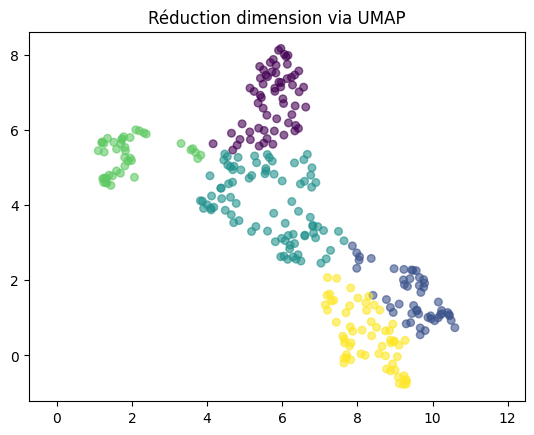

In [ ]:
plt.scatter(
    umap_result[:, 0],
    umap_result[:, 1],
    c=data['cluster'],
    alpha=0.6,
    s=30)
plt.gca().set_aspect('equal', 'datalim')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('Réduction dimension via UMAP')